In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Load datasets
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

#Add Labels
fake["label"] = 0 #Fake news
true["label"] = 1 #Real news

#Combine datasets
data = pd.concat([fake, true])

#Keep only required columns
data = data[["text", "label"]]

#Save file
data.to_csv("fake_news.csv", index=False)
print("File created Successfully")

#Display First 5 rows
print(data.head())

File created Successfully
                                                text  label
0  Donald Trump just couldn t wish all Americans ...      0
1  House Intelligence Committee Chairman Devin Nu...      0
2  On Friday, it was revealed that former Milwauk...      0
3  On Christmas day, Donald Trump announced that ...      0
4  Pope Francis used his annual Christmas Day mes...      0


In [ ]:
#check missing values
print(data.isnull().sum())

#Remove missing values
data = data.dropna()

text     0
label    0
dtype: int64


In [ ]:
#Text cleaning function
def clean_text(text):
  text = text.lower() # convert to Lowercase
  text = re.sub(r'[^a-zA-Z]', ' ', text) #remove special characters
  return text
#Apply cleaning
data['text'] = data['text'].apply(clean_text)

In [ ]:
print(data.head())

                                                text  label
0  donald trump just couldn t wish all americans ...      0
1  house intelligence committee chairman devin nu...      0
2  on friday  it was revealed that former milwauk...      0
3  on christmas day  donald trump announced that ...      0
4  pope francis used his annual christmas day mes...      0


In [ ]:
#Define input and output
X = data['text']
y = data['label']

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X = vectorizer.fit_transform(X)

In [ ]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
#Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

#Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

#SVM
svm = LinearSVC()
svm.fit(X_train, y_train)

#Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
#calculate accuracy of all models
nb_acc = accuracy_score(y_test, nb.predict(X_test))
lr_acc = accuracy_score(y_test, lr.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

#Print results
print("Naive Bayes Accuracy:", nb_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Random Forest Accuracy:", rf_acc)



Naive Bayes Accuracy: 0.9330734966592428
Logistic Regression Accuracy: 0.9860801781737194
SVM Accuracy: 0.994988864142539
Random Forest Accuracy: 0.9906458797327394


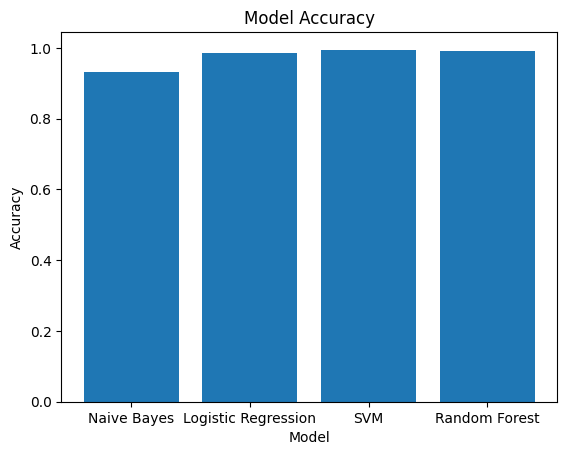

In [ ]:
models = ["Naive Bayes", "Logistic Regression", "SVM", "Random Forest"]
scores = [nb_acc, lr_acc, svm_acc, rf_acc]

plt.bar(models, scores)
plt.title("Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

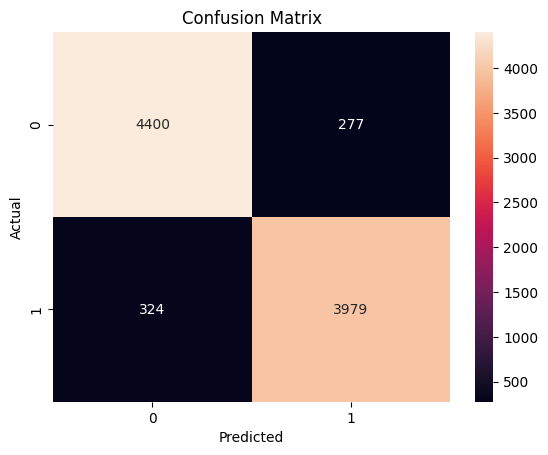

In [ ]:
#Confusion Matrix for Naive Bayes
cm = confusion_matrix(y_test, nb.predict(X_test))

sns.heatmap(cm, annot=True, fmt= 'd')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def check_news(news):
  news = clean_text(news)
  news_vec = vectorizer.transform([news])
  prediction = nb.predict(news_vec)
  if prediction[0] == 0:
    print("Fake News Detected")
  else:
    print("Real News Detected")

In [ ]:
while True:
  user_input = input("Enter news (or type 'exit' to stop): ")
  if user_input.lower() == 'exit':
    break

  check_news(user_input)

Enter news (or type 'exit' to stop): Government launches new scheme
Real News Detected
Enter news (or type 'exit' to stop): Scientists discover new medicine
Fake News Detected
Enter news (or type 'exit' to stop): stop
Fake News Detected
Enter news (or type 'exit' to stop): exit


In [ ]:
import pickle
#save model
pickle.dump(nb, open("model.pkl", "wb"))
#save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))